# Machine Learning and Deep Learning for Coastal Engineering

## Seminar Overview

This session introduces:
- Machine Learning fundamentals
- Deep Learning concepts
- Applications in coastal engineering

## Key questions
- How can we use data-driven models in coastal systems?
- What are the advantages over traditional approaches?

## Types of Data in Coastal Engineering

- **Time series (waves, tides)**
- Spatial data (bathymetry, shoreline)
- Spatio-temporal data (wave fields, currents)

## Machine Learning vs Deep Learning

### Machine Learning
- Random Forest
- Support Vector Machines
- Linear models

### Deep Learning
- Neural Networks
- CNNs
- LSTMs

## Typical Applications

- Wave forecasting
- Gap filling in buoy data
- Storm surge prediction
- Downscaling

## Time Series

A time series is a sequence of observations indexed in time.

Example:
Hs(t) = wave height at time t

Key properties:
- temporal dependence
- seasonality
- trends

**CARGAMOS LOS DATOS**

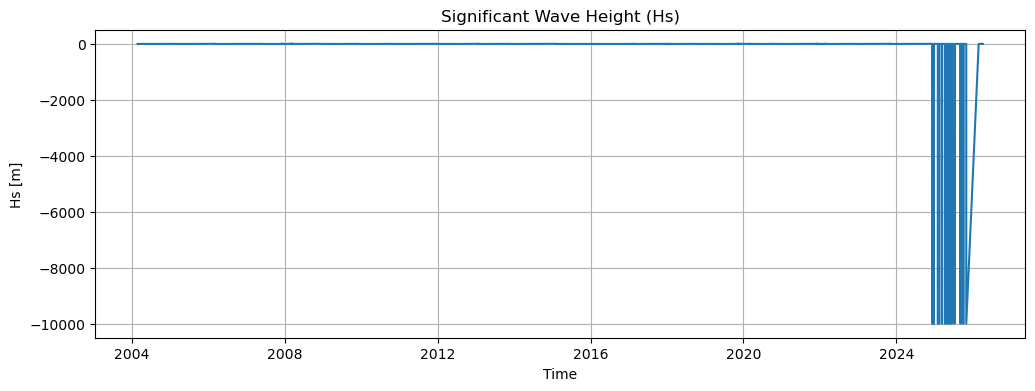

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")

# Preview
df.head()
# Convert date
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H")

# Set index
df.set_index("Fecha", inplace=True)
plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Data Quality Issues

When working with real coastal datasets, data quality problems are very common.

In this dataset, we observe:

- Presence of extreme values such as **-9999**
- These values do not represent physical measurements
- They are used as **missing data flags (NaN equivalents)**

### Why is this a problem?

- These values distort visualization
- They can completely break machine learning models
- They must be removed or properly handled before analysis

### Cleaning step

We replace invalid values (-9999) with NaN and remove them from the analysis.

After cleaning:
- The time series becomes physically meaningful
- However, **temporal gaps appear in the data**

These gaps are exactly the type of problem we aim to solve using Deep Learning methods such as LSTM.

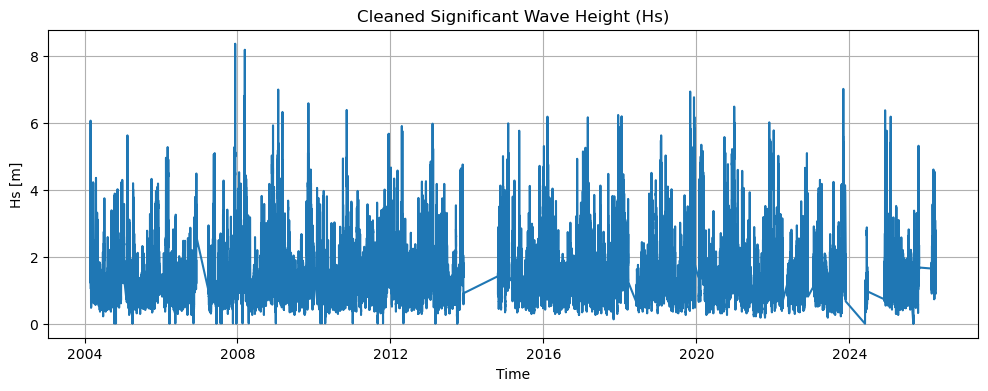

In [19]:
# Replace invalid values (-9999) with NaN
df["Hs"] = df["Hs"].replace(-9999.9, np.nan)

# Remove NaNs
df["Hs_clean"] = df["Hs"].replace(-9999.9, np.nan)

plt.figure(figsize=(12,4))
plt.plot(df_clean["Hs"])
plt.title("Cleaned Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Exploratory Data Analysis (EDA)

Before applying any machine learning model, it is essential to understand the data.

In this section, we will:
- analyze the distribution of the variables
- explore temporal patterns
- identify anomalies and gaps
- understand the structure of the dataset

This step is critical in any real data science workflow.

In [20]:
df["Hs_clean"].describe()

count    154854.000000
mean          1.419349
std           0.832627
min           0.000000
25%           0.830000
50%           1.200000
75%           1.780000
max           8.370000
Name: Hs_clean, dtype: float64

What values do we have?

In [22]:
import seaborn as sns
# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(7,4))

sns.histplot(
    df["Hs_clean"].dropna(),
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6
)

plt.title("Distribution of Significant Wave Height (Hs)", fontsize=12)
plt.xlabel("Hs [m]")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'